In [1]:
#!/usr/bin/env python
# coding: utf-8
"""
Ordinal Transition Network — Italy INGV Catalog (1985-2025)

Run as a script  : python ITALY_network_OTN.py
Convert to notebook: python convert_to_notebook.py ITALY_network_OTN.py notebooks/ITALY_network_OTN.ipynb
"""

import logging
from pathlib import Path
from itertools import permutations as _perms

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import networkx as nx
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.io as pio
import seaborn as sns

from src.network import build_ordinal_transition_network
from src.plotutils import setup_matplotlib, configure_saves, savefig, save_plotly

try:
    from IPython.display import display
except ImportError:
    display = print  # type: ignore[assignment]

logging.basicConfig(level=logging.INFO, format="%(levelname)s  %(message)s")
sns.set_theme(style="whitegrid")
pio.renderers.default = "notebook"

DATA_DIR    = Path("data/INGV")
RESULTS_DIR = Path("results")
RESULTS_DIR.mkdir(exist_ok=True)
(RESULTS_DIR / "data").mkdir(exist_ok=True)

CUT_YEAR = 1985

# OTN model parameters
OTN_WORD_SIZE = 4   # d! = 24 possible ordinal patterns
OTN_LAG       = 1   # stride between consecutive pattern windows (1 = overlapping)

SAVE_PDF: bool = True
SAVE_JPG: bool = True

setup_matplotlib()
configure_saves(SAVE_JPG, SAVE_PDF, RESULTS_DIR / "figures" / "italy" / "otn")

INFO  Figure saving ON → results/figures/italy/otn  (PDF=True JPG=True)


## Data Loading

The Italy INGV catalog covers $M \geq 1.5$ events from 1985–2025.

The Ordinal Transition Network (OTN) uses **only the magnitude sequence**
$\{m_0, m_1, \ldots, m_{N-1}\}$ in chronological order — spatial coordinates
are not used in network construction.  This makes the OTN the most stripped-down
model in the suite: it captures the **temporal ordering structure** of magnitudes
independently of where or how deep the earthquakes occurred.

**Important distinction:** The OTN produces a **tiny symbolic graph** with at most
$d! = 24$ nodes (for word size $d=4$), unlike all other models which produce 215k-node
graphs.  The analysis therefore focuses on pattern frequencies, entropy, and transition
dynamics rather than geographic maps or degree distributions.

**Expected output:** ~215,000 rows.  The magnitude column is what matters here.

In [2]:
print("Loading Italy earthquake catalog...")
df = pd.read_csv(DATA_DIR / "italy_earthquakes_1985_2025.csv")
df["time"] = pd.to_datetime(df["time"], utc=True)
df_net = (
    df[df["time"].dt.year >= CUT_YEAR]
    .sort_values("time")
    .reset_index(drop=True)
)
print(f"Loaded {len(df_net):,} earthquakes "
      f"({df_net['time'].dt.year.min()}–{df_net['time'].dt.year.max()})")
print(f"Magnitude range: {df_net['magnitude'].min():.1f}–{df_net['magnitude'].max():.1f}")
display(df_net[["time", "magnitude", "latitude", "longitude"]].head(5))

Loading Italy earthquake catalog...
Loaded 215,679 earthquakes (1985–2025)
Magnitude range: 1.5–6.8


,time,magnitude,latitude,longitude
0,1985-01-02 22:57:43.090000+00:00,2.6,41.715,13.941
1,1985-01-03 00:46:16.990000+00:00,2.5,41.677,13.931
2,1985-01-04 16:57:40.240000+00:00,3.8,46.158,7.174
3,1985-01-04 23:59:54.820000+00:00,3.7,45.338,6.641
4,1985-01-05 03:47:03.640000+00:00,3.2,45.409,6.627


## Ordinal Pattern Encoding

Each consecutive window of $d$ magnitudes is mapped to its **ordinal rank permutation**
$\pi \in S_d$ (the symmetry group of $d$ elements):

$$\pi_k = \text{argsort}(m_k, m_{k+1}, \ldots, m_{k+d-1})$$

For example, the window $[3.2,\ 1.1,\ 4.5,\ 2.0]$ has ranks $[2, 0, 3, 1]$
(position of each value in sorted order), corresponding to the pattern $(2,0,3,1)$.

For word size $d=4$, there are $4! = 24$ possible patterns.  With lag $\tau=1$
(overlapping windows), consecutive patterns share $d-1=3$ values — this is the
standard setting for **permutation entropy** (Bandt & Pompe 2002).

**Forbidden patterns** (permutations that never appear) indicate non-random structure.
For a purely i.i.d. magnitude series, all 24 patterns should appear with equal
probability $1/24 \approx 4.2\%$.  Deviations signal the Gutenberg-Richter law's
effect on the ordering: small magnitudes are far more common than large ones,
making some orderings (monotone ascending runs) statistically forbidden or rare.

**Expected output:** 24 pattern IDs; all or nearly all observed;
~215k windows for N=215k events with lag=1 (N - d + 1 windows).

In [3]:
G, patterns_arr = build_ordinal_transition_network(
    df_net, word_size=OTN_WORD_SIZE, lag=OTN_LAG,
)
n_canonical = len(list(_perms(range(OTN_WORD_SIZE))))  # d!
n_observed  = sum(1 for n in G.nodes() if G.nodes[n]["frequency"] > 0)
n_forbidden = n_canonical - n_observed
print(f"Word size d={OTN_WORD_SIZE}  →  {n_canonical} canonical patterns")
print(f"Observed: {n_observed}/{n_canonical}  |  Forbidden: {n_forbidden}")
print(f"Windows computed: {len(patterns_arr):,}  (lag={OTN_LAG})")

# Also compute timestamps aligned to pattern windows
t_window = df_net["time"].values[: len(patterns_arr)]  # start-of-window time

INFO  Building OTN: 215679 events, word_size=4, lag=1 ...
INFO  OTN: 24/24 patterns observed (0 forbidden), 215675 transitions — 1.3s


Word size d=4  →  24 canonical patterns
Observed: 24/24  |  Forbidden: 0
Windows computed: 215,676  (lag=1)


## OTN Construction

The **Ordinal Transition Network** (Pessa & Ribeiro 2019, *Physical Review E*, 100, 042304)
is the weighted directed graph where:

- **Nodes** $\pi_i$ are distinct ordinal patterns ($|\text{nodes}| \leq d!$)
- **Edges** $(\pi_i, \pi_j)$ exist iff pattern $\pi_i$ is immediately followed by
pattern $\pi_j$ in the time series, with **weight** = transition count $F_{ij}$

The OTN encodes the **short-memory dynamics** of the magnitude sequence:
how likely is it that the magnitude ordering in one window predicts the ordering
in the next window?

For a completely random i.i.d. series, all transitions are equally likely
($F_{ij} \approx N/d!^2$) and the OTN is an (approximately) complete
weighted directed graph on $d!$ nodes.

For seismic catalogs, aftershock sequences create **predictable transitions**:
after a large earthquake (high-ranking event in its window), the immediately
following events tend to be smaller (aftershock decay) — this creates systematic
pattern-to-pattern transitions that deviate from the random baseline.

**Expected output:** A directed graph on $\leq 24$ nodes; most or all of the
$24^2 = 576$ possible edges present (with varying weights); a few edges with
very high weight corresponding to the most common magnitude orderings in
aftershock sequences (monotone decreasing runs after mainshocks).

In [4]:
print(f"\nOTN structure:")
print(f"  Nodes: {G.number_of_nodes()}")
print(f"  Edges: {G.number_of_edges()}")
print(f"  Total transitions: {sum(d['weight'] for _,_,d in G.edges(data=True)):,}")
print(f"  Density: {G.number_of_edges() / (G.number_of_nodes()*(G.number_of_nodes()-1)):.3f}")

top_edges = sorted(G.edges(data=True), key=lambda e: e[2]["weight"], reverse=True)[:5]
print("\nTop 5 most frequent transitions:")
for u, v, d in top_edges:
    pl = G.nodes[u]["label"]
    ql = G.nodes[v]["label"]
    print(f"  {pl} → {ql}  (count={d['weight']:,})")


OTN structure:
  Nodes: 24
  Edges: 96
  Total transitions: 215,675
  Density: 0.174

Top 5 most frequent transitions:
  1230 → 0123  (count=6,589)
  0123 → 0123  (count=5,017)
  1203 → 0132  (count=4,857)
  2301 → 1230  (count=4,835)
  0123 → 3012  (count=4,722)


## Pattern Distribution

Bar chart of observed pattern frequencies vs the i.i.d. uniform baseline $1/d!$.

The **relative frequency** $p_k = f_k / \sum_k f_k$ for each pattern $k$ deviates
from the uniform $1/24 \approx 4.17\%$ baseline in a seismic catalog because:
1. **Gutenberg-Richter law:** small magnitudes are exponentially more common,
making monotone-decreasing patterns $(3,2,1,0)$ rare (requires four events each
larger than the previous — very unlikely when large events are rare).
2. **Omori law aftershock decay:** after a mainshock, the following events tend to
be smaller → magnitude-decreasing patterns are more common than increasing ones.

Bars are sorted by frequency; the dashed red line is the uniform baseline.

**Expected output:** Non-uniform distribution with some patterns 2–3× more common
than others.  Patterns involving monotone descents (consistent with aftershock decay)
should appear more frequently than monotone ascents.

INFO  Saved results/figures/italy/otn/pdf/otn_pattern_distribution_italy.pdf
INFO  Saved results/figures/italy/otn/jpg/otn_pattern_distribution_italy.jpg


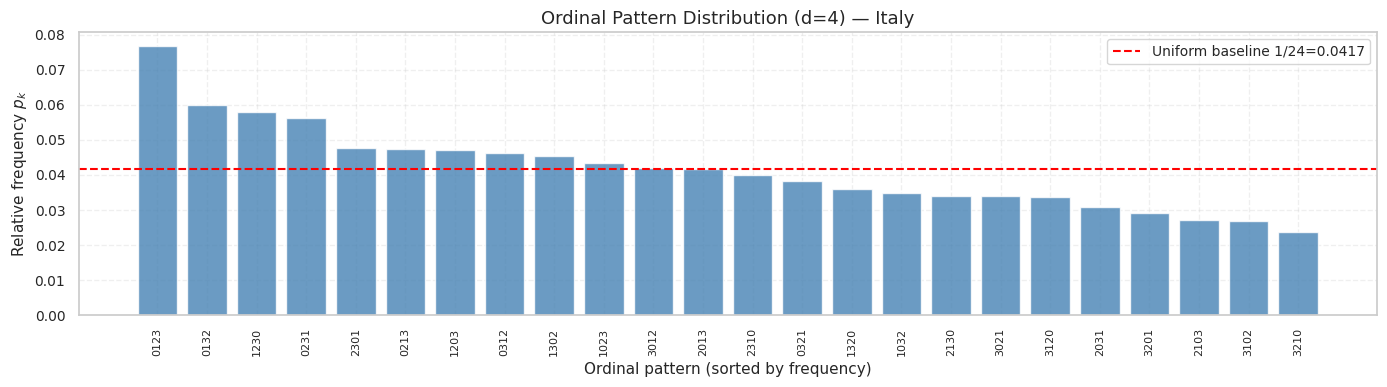

In [5]:
freq_arr = np.array([G.nodes[n]["frequency"] for n in sorted(G.nodes())])
labels   = [G.nodes[n]["label"] for n in sorted(G.nodes())]
total    = freq_arr.sum()
p_obs    = freq_arr / total
uniform  = 1.0 / n_canonical

order = np.argsort(p_obs)[::-1]

fig, ax = plt.subplots(figsize=(14, 4))
bars = ax.bar(range(n_canonical), p_obs[order], color="steelblue", alpha=0.8, width=0.8)
ax.axhline(uniform, color="red", linestyle="--", lw=1.5, label=f"Uniform baseline 1/{n_canonical}={uniform:.4f}")
ax.set_xticks(range(n_canonical))
ax.set_xticklabels([labels[i] for i in order], rotation=90, fontsize=8)
ax.set_xlabel("Ordinal pattern (sorted by frequency)")
ax.set_ylabel("Relative frequency $p_k$")
ax.set_title(f"Ordinal Pattern Distribution (d={OTN_WORD_SIZE}) — Italy")
ax.legend()
fig.tight_layout()
savefig("otn_pattern_distribution_italy")
plt.show()

## Forbidden Patterns

A **forbidden pattern** (Amigó et al. 2006) is an ordinal permutation that never
appears in the observed time series.  For a truly i.i.d. random process, all
patterns appear with probability 1 as $N \to \infty$.  Persistent forbidden patterns
therefore indicate **deterministic or constrained dynamics** in the magnitude sequence.

In seismic catalogs:
- Patterns requiring strict monotone ascents of all four consecutive magnitudes are
rare (not forbidden, but suppressed by Gutenberg-Richter).
- Truly forbidden patterns would indicate physically impossible magnitude orderings —
combinations that the seismic process never produces, regardless of catalog length.

*Reference:* Amigó, J. M., Zambrano, S., & Sanjuán, M. A. F. (2006).
True and false forbidden patterns in deterministic and random dynamics.
*EPL*, 79(5), 50001.

**Expected output:** For Italy's long catalog (~215k events), most or all 24 patterns
should appear at least once.  Zero or very few truly forbidden patterns, but patterns
with extremely low probability (< 0.1% of uniform) signal strong non-randomness.

In [6]:
print(f"\nForbidden patterns ({n_forbidden} total):")
forbidden_labels = [G.nodes[n]["label"] for n in G.nodes() if G.nodes[n]["frequency"] == 0]
if forbidden_labels:
    for lb in forbidden_labels:
        print(f"  Pattern {lb} — never observed")
else:
    print("  None — all 24 patterns observed at least once")

print("\nRarest patterns (bottom 5 by frequency):")
rare_order = np.argsort(p_obs)
for i in rare_order[:5]:
    print(f"  Pattern {labels[i]}: p={p_obs[i]:.5f}  ({freq_arr[i]:,} occurrences)")


Forbidden patterns (0 total):
  None — all 24 patterns observed at least once

Rarest patterns (bottom 5 by frequency):
  Pattern 3210: p=0.02370  (5,112 occurrences)
  Pattern 3102: p=0.02685  (5,791 occurrences)
  Pattern 2103: p=0.02725  (5,877 occurrences)
  Pattern 3201: p=0.02904  (6,264 occurrences)
  Pattern 2031: p=0.03081  (6,646 occurrences)


## Transition Matrix

The **row-normalised transition matrix** $T$ is the Markov chain on pattern space:

$$T_{ij} = \frac{F_{ij}}{\sum_j F_{ij}}$$

where $F_{ij}$ is the count of times pattern $i$ was immediately followed by
pattern $j$.  $T_{ij}$ is the probability that the magnitude sequence transitions
from pattern $i$ to pattern $j$ in one step.

**Diagonal dominance** ($T_{ii}$ large) indicates that the same pattern tends to
repeat — consistent with slow aftershock decay where the magnitude ordering changes
little from one window to the next.

**Off-diagonal structure** reveals which patterns tend to follow which others.
For seismic data, patterns representing "large event then smaller events" (e.g.
$(3,2,1,0)$ = monotone descent) should transition preferentially to patterns
representing "continued small events" (low-ranked first positions).

**Expected output:** A nearly-uniform matrix with mild structure; diagonal entries
slightly above $1/24 \approx 0.042$; a few off-diagonal entries $> 0.10$
corresponding to the most predictable pattern transitions in aftershock sequences.

/tmp/ipykernel_1576031/4110920157.py:10: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  T_mat    = np.divide(F_mat, row_sums, where=row_sums > 0)
INFO  Saved results/figures/italy/otn/pdf/otn_transition_matrix_italy.pdf
INFO  Saved results/figures/italy/otn/jpg/otn_transition_matrix_italy.jpg


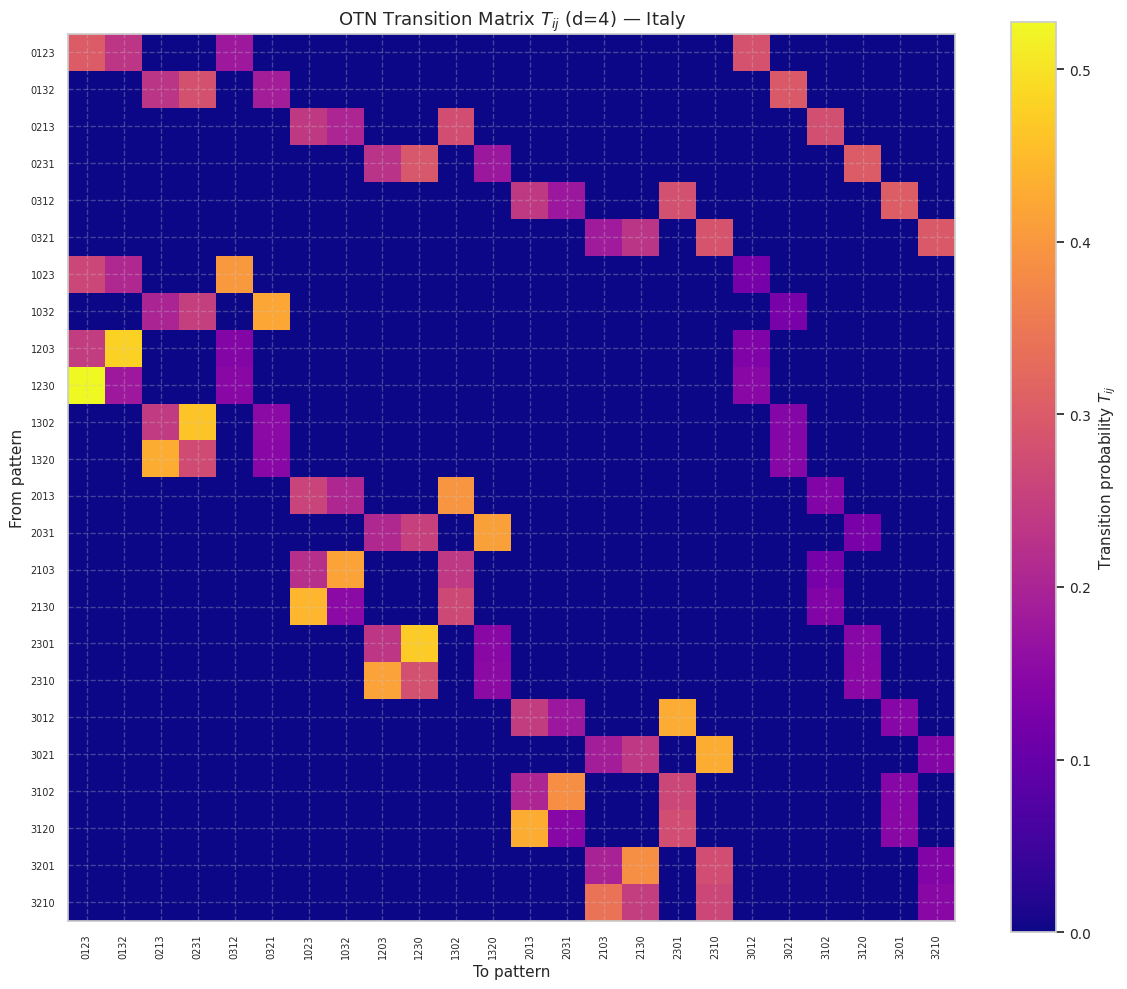

T matrix: min=0.0000  max=0.5273  mean diagonal=0.0187


In [7]:
# Build T matrix from OTN
node_ids = sorted(G.nodes())
n_pat    = len(node_ids)
node_idx = {n: i for i, n in enumerate(node_ids)}
F_mat    = np.zeros((n_pat, n_pat))
for u, v, d in G.edges(data=True):
    F_mat[node_idx[u], node_idx[v]] = d["weight"]

row_sums = F_mat.sum(axis=1, keepdims=True)
T_mat    = np.divide(F_mat, row_sums, where=row_sums > 0)

pat_labels = [G.nodes[n]["label"] for n in node_ids]

fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(T_mat, cmap="plasma", vmin=0, vmax=T_mat.max())
ax.set_xticks(range(n_pat)); ax.set_yticks(range(n_pat))
ax.set_xticklabels(pat_labels, rotation=90, fontsize=7)
ax.set_yticklabels(pat_labels, fontsize=7)
ax.set_xlabel("To pattern")
ax.set_ylabel("From pattern")
ax.set_title(f"OTN Transition Matrix $T_{{ij}}$ (d={OTN_WORD_SIZE}) — Italy")
fig.colorbar(im, ax=ax, label="Transition probability $T_{ij}$")
fig.tight_layout()
savefig("otn_transition_matrix_italy")
plt.show()

print(f"T matrix: min={T_mat.min():.4f}  max={T_mat.max():.4f}  mean diagonal={np.diag(T_mat).mean():.4f}")

## Stationary Distribution

The **stationary distribution** $\boldsymbol{\pi}$ satisfies $\boldsymbol{\pi} T = \boldsymbol{\pi}$
and is the left eigenvector of $T$ corresponding to eigenvalue 1.
It gives the long-run fraction of time the pattern sequence spends in each state —
i.e., how often each ordinal pattern appears in the limit of a very long catalog.

For a perfectly i.i.d. process, $\boldsymbol{\pi} = (1/d!, \ldots, 1/d!)$ (uniform).
Deviations indicate which patterns the seismic process prefers in the long run.

The stationary distribution is closely related to the observed pattern frequencies
$p_k$ but not identical: $p_k$ is the marginal frequency, while $\pi_k$ is the
long-run Markov frequency accounting for transition dynamics.  They agree exactly
when the Markov chain is reversible (detailed balance holds).

**Expected output:** $\pi_k$ approximately matches $p_k$ from the Pattern Distribution
section (consistency check).  The dominant pattern ($\pi_k$ largest) corresponds to
the most common magnitude ordering in the catalog — likely a pattern with descending
or mixed ranks, consistent with aftershock sequences following large events.

INFO  Saved results/figures/italy/otn/pdf/otn_stationary_distribution_italy.pdf
INFO  Saved results/figures/italy/otn/jpg/otn_stationary_distribution_italy.jpg


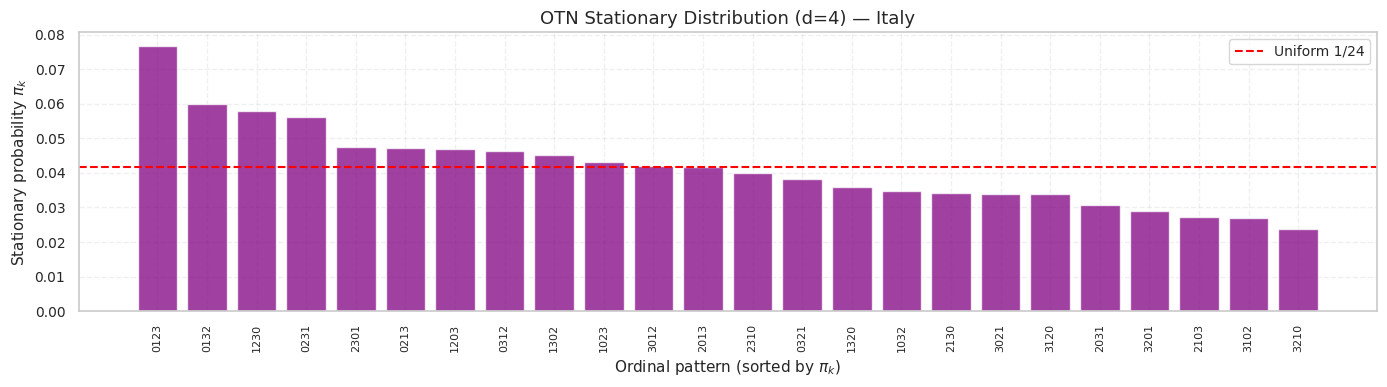

Stationary distribution: max=0.0769 (pattern 0123),  min=0.0237 (pattern 3210)
Deviation from uniform: L1 norm = 0.2233


In [8]:
eigvals, eigvecs = np.linalg.eig(T_mat.T)
# Stationary = left eigenvector of T with eigenvalue 1 → right eigenvector of T^T
idx_stat = np.argmax(np.real(eigvals))
pi       = np.real(eigvecs[:, idx_stat])
pi       = np.abs(pi) / np.abs(pi).sum()

order_pi = np.argsort(pi)[::-1]
fig, ax  = plt.subplots(figsize=(14, 4))
ax.bar(range(n_pat), pi[order_pi], color="purple", alpha=0.75, width=0.8)
ax.axhline(1.0/n_pat, color="red", linestyle="--", lw=1.5, label=f"Uniform 1/{n_pat}")
ax.set_xticks(range(n_pat))
ax.set_xticklabels([pat_labels[i] for i in order_pi], rotation=90, fontsize=8)
ax.set_xlabel("Ordinal pattern (sorted by $\\pi_k$)")
ax.set_ylabel("Stationary probability $\\pi_k$")
ax.set_title(f"OTN Stationary Distribution (d={OTN_WORD_SIZE}) — Italy")
ax.legend()
fig.tight_layout()
savefig("otn_stationary_distribution_italy")
plt.show()

print(f"Stationary distribution: max={pi.max():.4f} (pattern {pat_labels[order_pi[0]]}),  "
      f"min={pi.min():.4f} (pattern {pat_labels[order_pi[-1]]})")
print(f"Deviation from uniform: L1 norm = {np.abs(pi - 1.0/n_pat).sum():.4f}")

## Permutation Entropy

The **permutation entropy** (Bandt & Pompe 2002, *PRL* 88, 174102) measures the
complexity of the time series through its ordinal structure:

$$H_{\text{PE}} = -\sum_{k} p_k \log_2 p_k \Big/ \log_2(d!)$$

where $p_k$ is the relative frequency of pattern $k$.  $H_{\text{PE}}$ is
normalised to $[0, 1]$: $H = 1$ means perfectly random (all patterns equally likely),
$H = 0$ means completely deterministic (only one pattern ever appears).

For seismic catalogs:
- $H_{\text{PE}} \approx 0.95$–$1.00$: magnitude sequence is nearly i.i.d. → no
short-range ordering structure → Gutenberg-Richter randomness dominates.
- $H_{\text{PE}} < 0.90$: significant non-random ordering → aftershock sequencing
or magnitude clustering creates predictable magnitude patterns.

This single number summarises the entire OTN in terms of predictability.

**Expected output:** $H_{\text{PE}} \approx 0.92$–$0.99$.  Values significantly
below 1.0 confirm that the Omori-Utsu aftershock decay creates non-random magnitude
ordering — consecutive events after a mainshock tend to decrease in magnitude,
making certain ordinal patterns more likely than random.

In [9]:
p_nonzero   = p_obs[p_obs > 0]
H_PE_nats   = -np.sum(p_nonzero * np.log(p_nonzero))
H_PE_norm   = H_PE_nats / np.log(n_canonical)
H_PE_bits   = H_PE_nats / np.log(2)
H_max_bits  = np.log2(n_canonical)

print(f"Permutation Entropy H_PE (normalised, base e): {H_PE_norm:.6f}")
print(f"  (bits: {H_PE_bits:.4f} / {H_max_bits:.4f} max)")
print(f"  Departure from i.i.d.: {(1 - H_PE_norm)*100:.2f}%")

Permutation Entropy H_PE (normalised, base e): 0.987504
  (bits: 4.5277 / 4.5850 max)
  Departure from i.i.d.: 1.25%


## Entropy Rate

The **entropy rate** of the Markov chain captures the *conditional* complexity:
how much additional information is provided by knowing the current pattern when
predicting the next?

$$h = -\sum_{i} \pi_i \sum_{j} T_{ij} \log_2 T_{ij}$$

where $\pi$ is the stationary distribution and $T$ is the transition matrix.
Unlike $H_{\text{PE}}$ (which uses marginal frequencies), $h$ measures the
**conditional entropy** of each step given the previous pattern — the true
information-theoretic rate of the Markov chain.

For a memoryless i.i.d. process: $h = \log_2(d!) = \log_2(24) \approx 4.58$ bits/step.
For a fully deterministic sequence: $h = 0$.

If $h < H_{\text{PE}} \times \log_2(d!)$, the Markov chain has memory — knowing the
current pattern reduces uncertainty about the next, indicating sequential structure
in the magnitude time series.

**Expected output:** $h \approx 4.0$–$4.5$ bits/step (close to, but below, maximum);
the difference $\log_2(d!) - h$ measures the predictability gain from knowing the
current ordinal pattern.

In [10]:
H_rate_bits = 0.0
for i, n in enumerate(node_ids):
    if pi[i] > 0:
        row = T_mat[i]
        nz  = row[row > 0]
        H_rate_bits += pi[i] * (-np.sum(nz * np.log2(nz)))

H_max_rate  = np.log2(n_canonical)
print(f"Entropy rate h = {H_rate_bits:.4f} bits/step  (max = log₂({n_canonical}) = {H_max_rate:.4f})")
print(f"Normalised entropy rate: {H_rate_bits/H_max_rate:.6f}")
print(f"Predictability gain from Markov structure: {H_max_rate - H_rate_bits:.4f} bits/step")

Entropy rate h = 1.8910 bits/step  (max = log₂(24) = 4.5850)
Normalised entropy rate: 0.412444
Predictability gain from Markov structure: 2.6939 bits/step


## i.i.d. Baseline Comparison

Compare the observed $H_{\text{PE}}$ to the distribution expected under a null
hypothesis of i.i.d. magnitudes (random shuffles of the catalog).

Procedure: shuffle the magnitude sequence 200 times; compute $H_{\text{PE}}$
for each shuffle; compare to the observed value.

A $z$-score $z = (H_{\text{obs}} - \mu_{\text{null}}) / \sigma_{\text{null}} \ll 0$
confirms that the observed entropy is significantly lower than the i.i.d. baseline —
direct evidence of non-random magnitude ordering in the Italy catalog.

**Expected output:** Histogram of null $H_{\text{PE}}$ values concentrated near 1.0
(near-perfect randomness for shuffled catalogs); observed value marked as a vertical
line at $H_{\text{PE}} < 1.0$; $z$-score $< -3$ (very significant departure from i.i.d.).

Computing i.i.d. baseline (200 magnitude shuffles)…


INFO  Saved results/figures/italy/otn/pdf/otn_iid_baseline_italy.pdf
INFO  Saved results/figures/italy/otn/jpg/otn_iid_baseline_italy.jpg


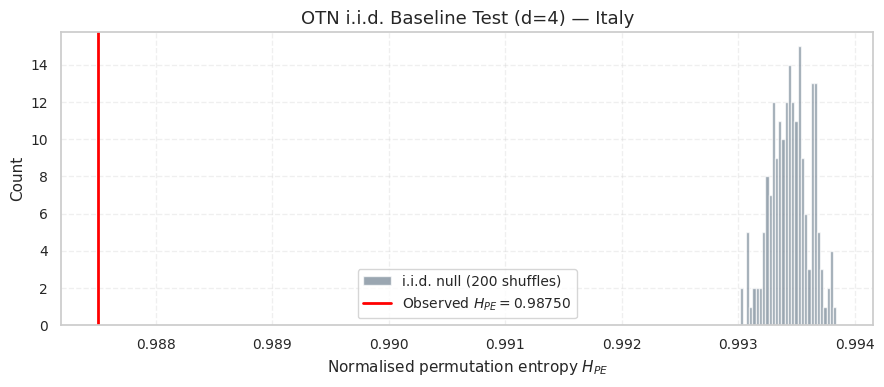

Null mean: 0.993451  std: 0.000171
Observed H_PE: 0.987504
z-score: -34.76  |  fraction of nulls ≤ observed: 0.0000


In [11]:
print("Computing i.i.d. baseline (200 magnitude shuffles)…")
rng      = np.random.default_rng(42)
mags_all = df_net["magnitude"].values.copy()
H_null   = []

for _ in range(200):
    m_shuf  = rng.permutation(mags_all)
    starts  = np.arange(0, len(m_shuf) - OTN_WORD_SIZE + 1, OTN_LAG)
    offsets = starts[:, None] + np.arange(OTN_WORD_SIZE)
    ranks   = np.argsort(m_shuf[offsets], axis=1, kind="stable")
    # fast frequency count via converting each row to an int (lex-rank)
    p_null_raw = np.unique(ranks.view(np.dtype((np.void, ranks.dtype.itemsize * OTN_WORD_SIZE))),
                           return_counts=True)[1].astype(float)
    p_null = p_null_raw / p_null_raw.sum()
    H_null.append(-np.sum(p_null * np.log(p_null)) / np.log(n_canonical))

H_null     = np.array(H_null)
z_score    = (H_PE_norm - H_null.mean()) / H_null.std()
p_val_est  = np.mean(H_null <= H_PE_norm)

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(H_null, bins=30, color="slategray", alpha=0.7, label="i.i.d. null (200 shuffles)")
ax.axvline(H_PE_norm, color="red", lw=2, label=f"Observed $H_{{PE}}={H_PE_norm:.5f}$")
ax.set_xlabel("Normalised permutation entropy $H_{PE}$")
ax.set_ylabel("Count")
ax.set_title(f"OTN i.i.d. Baseline Test (d={OTN_WORD_SIZE}) — Italy")
ax.legend()
fig.tight_layout()
savefig("otn_iid_baseline_italy")
plt.show()

print(f"Null mean: {H_null.mean():.6f}  std: {H_null.std():.6f}")
print(f"Observed H_PE: {H_PE_norm:.6f}")
print(f"z-score: {z_score:.2f}  |  fraction of nulls ≤ observed: {p_val_est:.4f}")

## Temporal Windowing

Rolling permutation entropy $H_{\text{PE}}(t)$ reveals how the complexity of the
magnitude sequence changes over time.  Computed in non-overlapping windows of
`WINDOW_EVENTS = 2000` events each (chosen to give ~20 windows per year for smooth
temporal resolution while maintaining enough events per window for stable entropy
estimation with 24 patterns).

A **drop in $H_{\text{PE}}$** before or after a large earthquake signals a period
of reduced magnitude randomness — consistent with a mainshock dominance followed by
aftershock decay creating a predictable monotone-decreasing pattern run.
A **return to high $H_{\text{PE}}$** marks the end of the aftershock sequence and
the resumption of background seismicity (more random magnitude ordering).

Major mainshocks marked on the plot:
- **1997 Umbria-Marche sequence** (M5.7, M6.0)
- **2009 L'Aquila** (M6.3)
- **2012 Emilia** (M6.1)
- **2016 Amatrice** (M6.2)

**Expected output:** $H_{\text{PE}}$ fluctuating around 0.93–0.99 with clear dips
immediately following the major mainshocks listed above.  Each dip reflects the
aftershock sequence imposing a deterministic ordering (large → progressively smaller)
on the magnitude time series within that window.

INFO  Saved results/figures/italy/otn/pdf/otn_temporal_windowing_italy.pdf
INFO  Saved results/figures/italy/otn/jpg/otn_temporal_windowing_italy.jpg


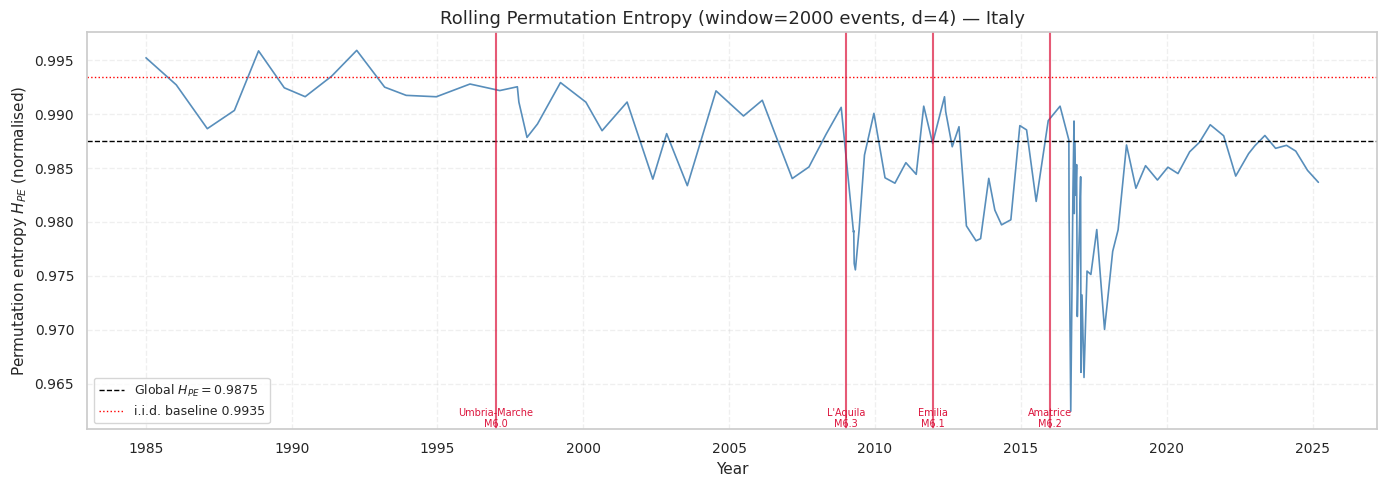

Rolling H_PE: min=0.9625 (window 65), max=0.9959 (window 8)


In [12]:
WINDOW_EVENTS = 2000
n_windows     = len(patterns_arr) // WINDOW_EVENTS
H_rolling     = np.empty(n_windows)
t_rolling     = np.empty(n_windows, dtype="datetime64[ns]")

for w in range(n_windows):
    s_pat   = w * WINDOW_EVENTS
    e_pat   = s_pat + WINDOW_EVENTS
    sub_pat = patterns_arr[s_pat:e_pat]
    freq_w  = np.bincount(sub_pat, minlength=n_canonical).astype(float)
    p_w     = freq_w / freq_w.sum()
    nz_w    = p_w[p_w > 0]
    H_rolling[w] = -np.sum(nz_w * np.log(nz_w)) / np.log(n_canonical)
    t_rolling[w] = t_window[s_pat]

t_rolling_dt = pd.to_datetime(t_rolling, utc=True)

# Major mainshocks in Italy catalog (year, label)
mainshocks = [
    (1997, "Umbria-Marche\nM6.0"),
    (2009, "L'Aquila\nM6.3"),
    (2012, "Emilia\nM6.1"),
    (2016, "Amatrice\nM6.2"),
]

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(t_rolling_dt, H_rolling, color="steelblue", lw=1.2, alpha=0.9)
ax.axhline(H_PE_norm, color="black", lw=1, linestyle="--", label=f"Global $H_{{PE}}={H_PE_norm:.4f}$")
ax.axhline(H_null.mean(), color="red", lw=1, linestyle=":", label=f"i.i.d. baseline {H_null.mean():.4f}")
for yr, label in mainshocks:
    t_ms = pd.Timestamp(f"{yr}-01-01", tz="UTC")
    ax.axvline(t_ms, color="crimson", lw=1.5, alpha=0.7)
    ax.text(t_ms, ax.get_ylim()[0] if ax.get_ylim()[0] > 0 else 0.90,
            label, fontsize=7, color="crimson", ha="center", va="bottom")
ax.set_xlabel("Year")
ax.set_ylabel("Permutation entropy $H_{PE}$ (normalised)")
ax.set_title(f"Rolling Permutation Entropy (window={WINDOW_EVENTS} events, d={OTN_WORD_SIZE}) — Italy")
ax.legend(fontsize=9)
fig.tight_layout()
savefig("otn_temporal_windowing_italy")
plt.show()

print(f"Rolling H_PE: min={H_rolling.min():.4f} (window {H_rolling.argmin()}), "
      f"max={H_rolling.max():.4f} (window {H_rolling.argmax()})")

## Export Results

The OTN analysis produces three CSV files rather than a pickle/GEXF (the graph
has ≤24 nodes and is trivially small).

**`italy_otn_pattern_frequencies.csv`**: pattern ID, tuple string, label, frequency,
relative frequency, and stationary probability for all 24 patterns.

**`italy_otn_transition_matrix.csv`**: the full $24 \times 24$ row-normalised
transition matrix $T_{ij}$, with row/column labels.

**`italy_otn_entropy_timeseries.csv`**: rolling $H_{\text{PE}}$ with timestamps,
for use in the comparison notebook or further temporal analysis.

**Expected output:** Three small CSVs.  The entropy timeseries CSV has ~100 rows
(one per 2000-event window); the pattern frequency CSV has 24 rows; the transition
matrix CSV has 24 rows × 24 columns.

In [13]:
df_patterns_out = pd.DataFrame({
    "pattern_id":    node_ids,
    "pattern_tuple": [str(G.nodes[n]["pattern_tuple"]) for n in node_ids],
    "label":         pat_labels,
    "frequency":     [G.nodes[n]["frequency"] for n in node_ids],
    "rel_frequency": [G.nodes[n]["frequency"] / total for n in node_ids],
    "stationary_pi": pi,
})
p1 = RESULTS_DIR / "data" / "italy_otn_pattern_frequencies.csv"
df_patterns_out.to_csv(p1, index=False)
print(f"Pattern frequencies → {p1}")

df_T = pd.DataFrame(T_mat, index=pat_labels, columns=pat_labels)
p2   = RESULTS_DIR / "data" / "italy_otn_transition_matrix.csv"
df_T.to_csv(p2)
print(f"Transition matrix → {p2}")

df_entropy_ts = pd.DataFrame({
    "window_start": t_rolling_dt,
    "H_PE":         H_rolling,
})
p3 = RESULTS_DIR / "data" / "italy_otn_entropy_timeseries.csv"
df_entropy_ts.to_csv(p3, index=False)
print(f"Entropy timeseries → {p3}")

print(f"\nSummary:")
print(f"  H_PE = {H_PE_norm:.6f}  (z = {z_score:.2f} vs i.i.d.)")
print(f"  h_rate = {H_rate_bits:.4f} bits/step  (max {H_max_rate:.4f})")
print(f"  Forbidden patterns: {n_forbidden}/{n_canonical}")

Pattern frequencies → results/data/italy_otn_pattern_frequencies.csv
Transition matrix → results/data/italy_otn_transition_matrix.csv
Entropy timeseries → results/data/italy_otn_entropy_timeseries.csv

Summary:
  H_PE = 0.987504  (z = -34.76 vs i.i.d.)
  h_rate = 1.8910 bits/step  (max 4.5850)
  Forbidden patterns: 0/24
